# **1.Installing Libraries and Packages**

In [1]:
!pip uninstall transformers -y
!pip install transformers==4.44.2
!pip install datasets

Found existing installation: transformers 4.53.3
Uninstalling transformers-4.53.3:
  Successfully uninstalled transformers-4.53.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 73.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 80.8 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.0.0rc2
    Uninstalling huggingface-hub-1.0.0rc2:
      Successfully uninstalled huggingface-hub-1.0.0rc2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflic

In [2]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
!pip install -U transformers huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 105.8 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.6 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.44.2
    Uninstalling transformers-4.44.2:
      Successfully uninstalled transformers-4.44.2


In [4]:
!pip install keras_self_attention

  Preparing metadata (setup.py) ... done
  Created wheel for keras_self_attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=69b8e8a8a72b146bf34892089752e62bf32cd33b4e31d90d858e3a3d1224778c
  Stored in directory: /root/.cache/pip/wheels/46/f9/96/709295c836133071c12a300729fed4027757f889c01695feea
Successfully built keras_self_attention


In [5]:
!pip install emoji
import emoji

In [6]:
!pip install tensorflow

In [7]:
!pip install fasttext==0.9.2 -q
import fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# **2.Importing Libraries**

In [8]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
from typing import Set
TARGET_LABELS: Set[str] = {"PERSON", "ORG", "GPE", "PRODUCT","NORP","LAW","FAC","EVENT"}
SPACY_MODEL: str = "en_core_web_lg" # Recommended model for balance of speed and accuracy
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preprocessed-data/preprocessed  sentiment analysis data.csv
/kaggle/input/twitter-and-reddit-sentimental-analysis-dataset/Twitter_Data.csv
/kaggle/input/twitter-and-reddit-sentimental-analysis-dataset/Reddit_Data.csv
/kaggle/input/english-words-corpus/words_alpha.txt
/kaggle/input/cc-en-300-bin/cc.en.300.bin
/kaggle/input/stop-hinglish/stop_hinglish.txt


In [9]:
import spacy
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
import tensorflow as tf 
from tensorflow import keras 
%matplotlib inline


2025-12-06 14:31:06.883385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765031467.077245      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765031467.134997      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [10]:
import glob

In [10]:
pd.set_option('display.max_colwidth', None)
df_twitter=pd.read_csv('/kaggle/input/twitter-and-reddit-sentimental-analysis-dataset/Twitter_Data.csv',encoding='utf-8')
df_reddit=pd.read_csv('/kaggle/input/twitter-and-reddit-sentimental-analysis-dataset/Reddit_Data.csv',encoding='utf-8')

In [ ]:
df_twitter

In [100]:
df_twitter.rename(columns={'clean_text':'text'},inplace=True)


In [101]:
df_count_twit=pd.DataFrame(df_twitter['category'].value_counts())
df_count_twit=df_count_twit.reset_index()
df_count_twit

,category,count
0,1.0,72250
1,0.0,55213
2,-1.0,35510


# **3.Exploratory Data Analysis and Visualization**

<Axes: xlabel='category', ylabel='count'>

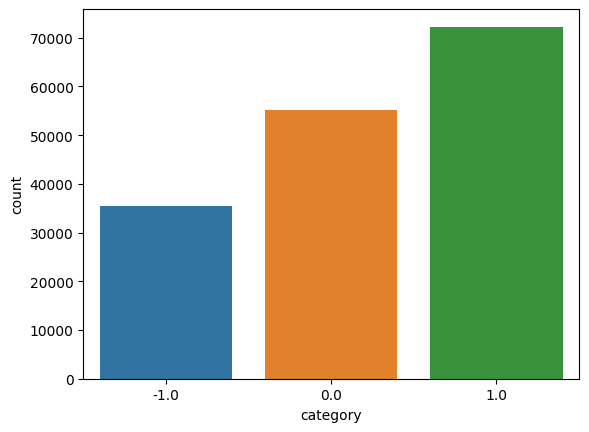

In [102]:
sns.barplot(data=df_count_twit,x='category',y='count')

In [103]:
df_reddit=pd.DataFrame(df_reddit)
df_reddit

,clean_comment,category
0,family mormon have never tried explain them they still stare puzzled from time time like some kind strange creature nonetheless they have come admire for the patience calmness equanimity acceptance and compassion have developed all the things buddhism teaches,1
1,buddhism has very much lot compatible with christianity especially considering that sin and suffering are almost the same thing suffering caused wanting things shouldn want going about getting things the wrong way christian this would mean wanting things that don coincide with god will and wanting things that coincide but without the aid jesus buddhism could also seen proof god all mighty will and omnipotence certainly christians are lucky have one such christ there side but what about everyone else well many christians believe god grace salvation and buddhism god way showing grace upon others would also help study the things jesus said and see how buddha has made similar claims such rich man getting into heaven joke basically advocating that should rid ourselves material possessions fact distinctly remembered jesus making someone cry because that someone asked what achieve salvation and jesus replied with live like buddhist very very roughly translated also point out that buddha rarely spoke anything about god theory personally because knew well enough leave that jesus and mohamed who came later just remember conflict difference opinion but education can fun involving and enlightening easier teach something than prove right like intelligent design,1
2,seriously don say thing first all they won get its too complex explain normal people anyway and they are dogmatic then doesn matter what you say see mechante post and for any reason you decide later life move from buddhism and that doesn suit you identity though you still get keep all the wisdom then your family will treat you like you went through weird hippy phase for while there didncha and you never hear the end pro tip don put one these your wall jpg,-1
3,what you have learned yours and only yours what you want teach different focus the goal not the wrapping paper buddhism can passed others without word about the buddha,0
4,for your own benefit you may want read living buddha living christ thich nhat hanh you might find any subsequent discussions with your loved ones easier you are able articulate some the parallels that exist between buddhism and christianity don surprised they react negatively for having lost you treat them with compassion and deserved understanding although they may indeed display signs being hurt your new path properly sharing with them way that may alleviate their fear something they may perceive wrong the very least alien their beliefs may help allowing them the long run accept although not necessarily agree with your decision regardless where they end you have make your own way,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab saal khatam hone hai sala tune bhi chutiya bana diya,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [104]:
df_count_red=pd.DataFrame(df_reddit['category'].value_counts())
df_count_red=df_count_red.reset_index()
df_count_red

,category,count
0,1,15830
1,0,13142
2,-1,8277


<Axes: xlabel='category', ylabel='count'>

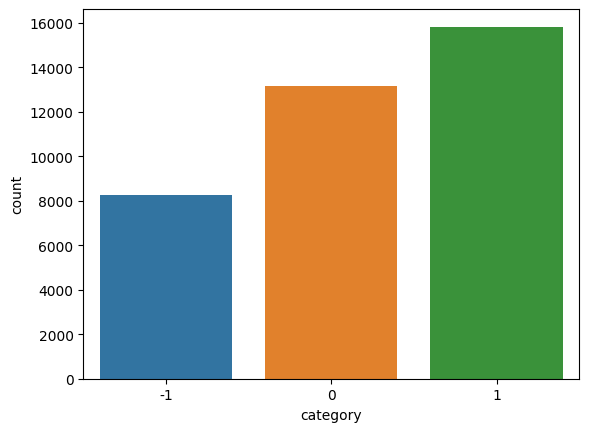

In [105]:
sns.barplot(data=df_count_red,x='category',y='count')

In [106]:
df_reddit.rename(columns={'clean_comment':'text'},inplace=True)
df_reddit

,text,category
0,family mormon have never tried explain them they still stare puzzled from time time like some kind strange creature nonetheless they have come admire for the patience calmness equanimity acceptance and compassion have developed all the things buddhism teaches,1
1,buddhism has very much lot compatible with christianity especially considering that sin and suffering are almost the same thing suffering caused wanting things shouldn want going about getting things the wrong way christian this would mean wanting things that don coincide with god will and wanting things that coincide but without the aid jesus buddhism could also seen proof god all mighty will and omnipotence certainly christians are lucky have one such christ there side but what about everyone else well many christians believe god grace salvation and buddhism god way showing grace upon others would also help study the things jesus said and see how buddha has made similar claims such rich man getting into heaven joke basically advocating that should rid ourselves material possessions fact distinctly remembered jesus making someone cry because that someone asked what achieve salvation and jesus replied with live like buddhist very very roughly translated also point out that buddha rarely spoke anything about god theory personally because knew well enough leave that jesus and mohamed who came later just remember conflict difference opinion but education can fun involving and enlightening easier teach something than prove right like intelligent design,1
2,seriously don say thing first all they won get its too complex explain normal people anyway and they are dogmatic then doesn matter what you say see mechante post and for any reason you decide later life move from buddhism and that doesn suit you identity though you still get keep all the wisdom then your family will treat you like you went through weird hippy phase for while there didncha and you never hear the end pro tip don put one these your wall jpg,-1
3,what you have learned yours and only yours what you want teach different focus the goal not the wrapping paper buddhism can passed others without word about the buddha,0
4,for your own benefit you may want read living buddha living christ thich nhat hanh you might find any subsequent discussions with your loved ones easier you are able articulate some the parallels that exist between buddhism and christianity don surprised they react negatively for having lost you treat them with compassion and deserved understanding although they may indeed display signs being hurt your new path properly sharing with them way that may alleviate their fear something they may perceive wrong the very least alien their beliefs may help allowing them the long run accept although not necessarily agree with your decision regardless where they end you have make your own way,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab saal khatam hone hai sala tune bhi chutiya bana diya,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [107]:
df=pd.concat([df_twitter,df_reddit])
df

,text,category
0,when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples,-1.0
1,talk all the nonsense and continue all the drama will vote for modi,0.0
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,1.0
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass filthy nonsensical see how most abuses are coming from chowkidars,1.0
4,answer who among these the most powerful world leader today trump putin modi may,1.0
...,...,...
37244,jesus,0.0
37245,kya bhai pure saal chutiya banaya modi aur jab saal khatam hone hai sala tune bhi chutiya bana diya,1.0
37246,downvote karna tha par upvote hogaya,0.0
37247,haha nice,1.0


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200229 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   text      200125 non-null  object 
 1   category  200222 non-null  float64
dtypes: float64(1), object(1)
memory usage: 4.6+ MB


In [109]:
df.shape

(200229, 2)

In [110]:
df_count=pd.DataFrame(df['category'].value_counts())
df_count=df_count.reset_index()
df_count

,category,count
0,1.0,88080
1,0.0,68355
2,-1.0,43787


<Axes: xlabel='category', ylabel='count'>

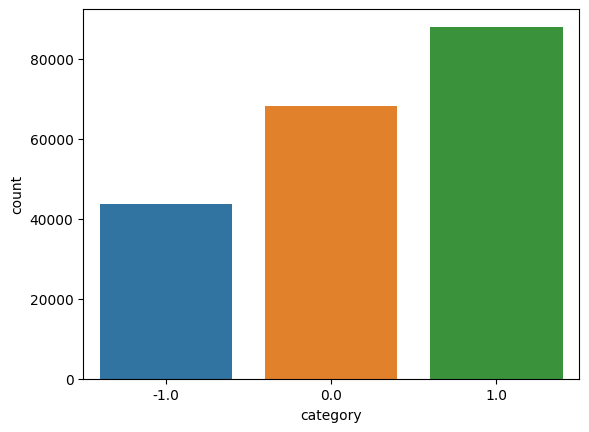

In [111]:
sns.barplot(data=df_count,x='category',y='count')

In [112]:
df.isnull().sum()

text        104
category      7
dtype: int64

In [113]:
df.dropna(inplace=True)

In [114]:
df.isnull().sum()

text        0
category    0
dtype: int64

In [115]:
df.duplicated().sum()

410

In [116]:
df.drop_duplicates(inplace=True)

In [117]:
df.duplicated().sum()

0

In [118]:
df_cat_count=pd.DataFrame(df['category'].value_counts())
df_cat_count=df_cat_count.reset_index()
df_cat_count

,category,count
0,1.0,87992
1,0.0,67961
2,-1.0,43755


In [119]:
min_undersample=df_cat_count['count'].min()
min_undersample

43755

In [120]:
df_neutral=df[df['category']==0].sample(frac=1,random_state=77).reset_index(drop=True)
df_neutral=df_neutral[:min_undersample]
df_neutral

,text,category
0,terrorism pakistan and demonization muslims have always been central modi’ and bjp’ politics,0.0
1,shooting during nda daily shooting during upa respected fisher women gives clarity initiatives modi govt which transformed their life,0.0
2,political backing are you kidding\nhis uncle ravi subramanya time bjp mla from basavanagudi the same loksabha constituency dynasty and has political backing from rss\nmodi picked him take take revenge ananthkumar was advani camp,0.0
3,during the tenure modi one point happening only which privatization profit and socialisation losses,0.0
4,morning dose huncho,0.0
...,...,...
43750,inch sina drdo exchief mission shakti upa didn’ give nod but modi had the courage\n,0.0
43751,and that time modi insults farmer givng just 6000 year,0.0
43752,modi saphat lega may,0.0
43753,streanh for everyone,0.0


In [121]:
df_positive=df[df['category']==1].sample(frac=1,random_state=77).reset_index(drop=True)
df_positive=df_positive[:min_undersample]
df_positive

,text,category
0,never seen advani having laugh even smiling like this with modi,1.0
1,problem that their hatred for modi trumps their love for india,1.0
2,like said unreasonable downvoting happens both sides see this thread the latest example own replies got downvoted for asking valid questions aap edit and now this post too intolerance not specific party,1.0
3,little more than two years ago modi said that with the back bone terrorism was destroyed know our backbone was hurt standing queue withdraw our own money but your handling kashmiri issue and its people was inapt and neither was terrorism impacted,1.0
4,where have proper clean drains their own family from codecademy and bmc hence all his father lived the software that you have worked can right now,1.0
...,...,...
43750,anti chandrababu factor dominating many factors like special status jagan corruption anti modi anti kcr politics,1.0
43751,one thing for sure more these opposition party members abuse modi more are the chances these desparate opposition loosing the election wonder that these shameless politicians will stoop down much lower and hurl much more low grade abuses modi,1.0
43752,what the most important story you have covered according you,1.0
43753,called refer the cobrapost operation 136 regarding how easily pay and push agenda through the indian media ´ super obvious what´ happening usa trying the same thing except they are failing but india got the recipe right create urgency and rise nationalism close elections make opposition look like anti nationals and then claim the countrys only saviour from this exaggerated self inflicted crisis,1.0


In [122]:
df_negative=df[df['category']==-1]
df_negative

,text,category
0,when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples,-1.0
15,vote such party and leadershipwho can take fast and firm action none other than narendra damodardas modi and bjp party,-1.0
19,didn’ write chowkidar does mean ’ anti modi try visit the plz not all who haven’ used are anti,-1.0
21,with firm belief the leadership shri narendra modi bjp entering into politics given form file nomination for the khammam parliamentary seat proceeding khammam today,-1.0
23,sultanpur uttar pradesh loksabha candidate select pawan kumar pandey actually public want given vote modi but your current condidate not popular district your candidate bsp candidate sonbhadra singh,-1.0
...,...,...
37184,how else supposed ask for your vote only violation illegally influencing you vote for particular candidate asking for you vote for them violation then everyone will guilty,-1.0
37193,modi like trump obsessed who criticizing him media narcissist don like criticism even though its constructive one,-1.0
37204,fuck you nearly had want rush the atm,-1.0
37209,seriously the india hasn done any press conferences and you guys still vote for this guy pakistani does talk the nation every week but modi doesn bother talking those who voted for him wtf,-1.0


In [123]:
df=pd.concat([df_positive,df_neutral,df_negative]).sample(frac=1,random_state=55).reset_index(drop=True)
df

,text,category
0,once again modi government ✌️,0.0
1,who listening him and even following him\nand the way how come modi india comes here\nimran confessing hindus migrating\nidiot,-1.0
2,migos,0.0
3,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019,0.0
4,modi gesturewas quite different confident overconfident,1.0
...,...,...
131260,shit what even the point then nah but really what odd thing change,-1.0
131261,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,-1.0
131262,the mods kill yourselves,0.0
131263,nice video thanx modi wanna thank him again after ls19 vote modi\njai hind,1.0


In [124]:
df[130000:]

,text,category
130000,unity diversity devlopment jati vad destruction modi make every body all jati golden jati indian,1.0
130001,literally can vote for modi because don live either benaras baroda,1.0
130002,how does cia investigates the matters outside usa how usa approves such investigations isn illegal,-1.0
130003,election tracker live modi mocked mgnrega too says rahul gandhi criticism his income promise,1.0
130004,you hit the nail the head arguing with modi bhakt like throwing stone pile shit have bear the shifty smell matter what,-1.0
...,...,...
131260,shit what even the point then nah but really what odd thing change,-1.0
131261,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,-1.0
131262,the mods kill yourselves,0.0
131263,nice video thanx modi wanna thank him again after ls19 vote modi\njai hind,1.0


In [125]:
df_count=pd.DataFrame(df['category'].value_counts())
df_count=df_count.reset_index()
df_count

,category,count
0,0.0,43755
1,-1.0,43755
2,1.0,43755


<Axes: xlabel='category', ylabel='count'>

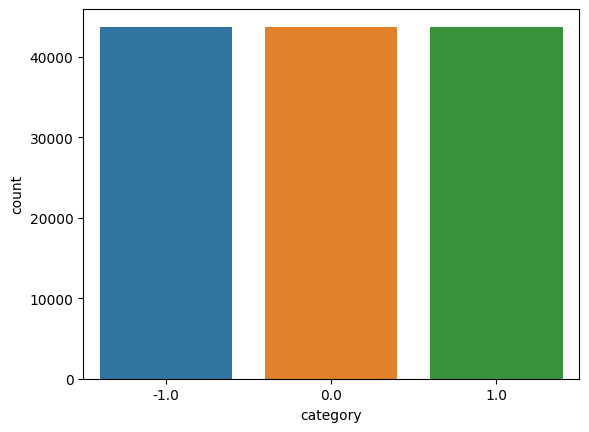

In [126]:
sns.barplot(data=df_count,x='category',y='count')

# **4.Text Preprocessing and cleaning**

In [127]:
def cleaning_function(data):
    content = emoji.demojize(data)
    content=re.sub(r'[()@<>\'#%$&*/\\_:""]',' ',content)
    content = re.sub(r'(.)\1{2,}', r'\1', content)
    content = re.sub(r"http\S+|www\S+"," ",content)
    content=re.sub('\s+',' ',content).strip()
    return content

In [128]:
df['clean_text']=df['text'].apply(cleaning_function)
df['clean_text']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                        once again modi government victory hand
1                                                                                                                                                                                                                                                                                                                                                                                    who listening him and even following him and the way how come modi india comes here imran confessing hindus migrating idiot
2     

In [129]:
df

,text,category,clean_text
0,once again modi government ✌️,0.0,once again modi government victory hand
1,who listening him and even following him\nand the way how come modi india comes here\nimran confessing hindus migrating\nidiot,-1.0,who listening him and even following him and the way how come modi india comes here imran confessing hindus migrating idiot
2,migos,0.0,migos
3,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019,0.0,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019
4,modi gesturewas quite different confident overconfident,1.0,modi gesturewas quite different confident overconfident
...,...,...,...
131260,shit what even the point then nah but really what odd thing change,-1.0,shit what even the point then nah but really what odd thing change
131261,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,-1.0,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails
131262,the mods kill yourselves,0.0,the mods kill yourselves
131263,nice video thanx modi wanna thank him again after ls19 vote modi\njai hind,1.0,nice video thanx modi wanna thank him again after ls19 vote modi jai hind


****

# **5.Removing Stop words and Hinglsih Words for Classical Machine and deep learning models**

In [130]:
hinglish_stopwords_pathfile='/kaggle/input/stop-hinglish/stop_hinglish.txt'
with open(hinglish_stopwords_pathfile,'r',encoding='utf-8') as file:
    text=file.read()
hinglish_stopwords=set(text.split('\n'))
print(hinglish_stopwords)

{'across', '', 'will', 'kin', 'wasn', 'bandi', 'didnt', 'tune', 'first', 'accha', 'bata', 'bani', 'always', 'hota', "it's", 'off', 'kahin', 'kinko', "weren't", 'hm', 'shall', 'theek', 'kari', 'haven', 'new', 'wo', 'dega', 'jiska', 'far', 'mai', 'truly', 'fifth', 'somehow', 'abe', 'ise', 'wala', 'jinho', 'okay', 'dekho', "c'mon", 'has', 'karna', 'rakh', 'get', 'enough', 'tumhare', 'aaj', 'bahut', "i'd", 'phle', 'while', 'willing', 'yup', 'ho', 'nor', 'tries', 'apna', 'tumhari', "there's", 'about', 'kinn', 'nhi', 'who', 'comes', 'five', 'than', 'li', 'kuch', 'through', 't', 'true', 'under', 'anyway', 'um', 'quite', 'kyunki', 'in', 'bad', 'own', 'becoming', 'nai', 'although', 'kayi', 'unse', 'came', 'too', 'into', 'each', 'chalega', 'that', 'which', 'meri', 'outside', 'upar', 'kyu', 'kul', 'others', 'doosra', "i'm", 'it', 'until', 'nope', 'against', 'honge', 'tends', 'whenever', 'beside', 'more', 'least', 'twice', 'useful', 'seemed', 'given', 'hum', 'thats', 'hue', 'sakti', 'anyways', 'ho

In [131]:
print(nlp.Defaults.stop_words)

{'across', 'will', 'first', 'always', 'off', 'somehow', 'has', 'get', 'enough', 'former', 'while', 'nor', 'about', 'who', 'five', 'than', 'through', "'d", 'under', 'anyway', 'quite', 'in', 'own', 'becoming', 'although', 'front', 'too', 'indeed', 'into', 'each', '’re', 'that', 'which', 'others', 'it', 'empty', 'until', 'against', 'whenever', 'beside', 'more', 'least', 'seemed', "'s", 'how', 'nowhere', 'often', 'yourselves', 'anyhow', 'its', 'various', 'unless', 'therein', 'several', 'part', 'hundred', 'sixty', 'itself', 'becomes', 'bottom', 'become', 'such', 'yet', 'except', 'whether', 'already', 'move', 'without', 'as', 'very', 'go', 'well', 'last', 'did', 'not', 'everyone', 'once', 'what', 'she', 'among', 'our', 'please', 'done', 'someone', 'may', 'would', 'yourself', 'themselves', '’s', 'per', 'down', 'eleven', 'me', 'out', 'the', 'therefore', 'should', 'does', 'so', 'with', 'see', 'whose', 'being', '‘ve', 'ever', 'show', 'afterwards', 'hereby', 'hereafter', 'whereby', 'them', 'up', 

In [132]:
from nltk.corpus import stopwords

spacy_stopwords = nlp.Defaults.stop_words

nltk_stopwords = set(stopwords.words('english'))

In [133]:
combined_stopwords = spacy_stopwords.union(nltk_stopwords,hinglish_stopwords)
print(len(combined_stopwords), "combined stopwords")


1098 combined stopwords


In [134]:
English_dictionary_pathfile='/kaggle/input/english-words-corpus/words_alpha.txt'
with open(English_dictionary_pathfile,'r',encoding='utf-8') as file:
    text=file.read()
English_dictionary=set(text.split('\n'))
len(English_dictionary)

370106

In [135]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import words
from nltk.corpus import brown
from nltk.corpus import words, brown, wordnet, cmudict
nltk.download(['words', 'brown', 'wordnet', 'cmudict', 'stopwords'], quiet=True)
# Get all categories
categories=brown.categories()
brown= set(brown.words(categories=categories))
spacy_words = set(lex.text.lower() for lex in nlp.vocab if lex.is_alpha)
nltk_words = set(w.lower() for w in words.words())
brown_words = set(w.lower() for w in brown)
cmudict_words = set(cmudict.dict().keys())
english_vocabs = spacy_words.union( brown_words,nltk_words,cmudict_words,English_dictionary)

len(english_vocabs)

448035

In [136]:
lemmatizer = WordNetLemmatizer()


def spacy_to_wordnet_pos(spacy_pos):
    if spacy_pos.startswith("V"):
        return wordnet.VERB
    elif spacy_pos.startswith("N"):
        return wordnet.NOUN
    elif spacy_pos.startswith("J"):
        return wordnet.ADJ
    elif spacy_pos.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN  


docs = nlp.pipe(df['clean_text'].astype(str),batch_size=512,n_process=3,disable=["ner", "parser"])

In [137]:
def preprocess_docs(docs):
    return [
        ' '.join([
            lemmatizer.lemmatize(token.text.lower(), spacy_to_wordnet_pos(token.tag_))
            for token in doc
            if ( (token.is_alpha 
                and token.text.lower() not in combined_stopwords)
                and (token.text.lower() in english_vocabs) )
        ])
        for doc in docs
    ]

df['w/o s_w tokens'] = preprocess_docs(docs)

In [138]:
df

,text,category,clean_text,w/o s_w tokens
0,once again modi government ✌️,0.0,once again modi government victory hand,modi government victory hand
1,who listening him and even following him\nand the way how come modi india comes here\nimran confessing hindus migrating\nidiot,-1.0,who listening him and even following him and the way how come modi india comes here imran confessing hindus migrating idiot,listen modi india confess hindu migrate idiot
2,migos,0.0,migos,
3,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019,0.0,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019,prime minister narendra modi address nation lok election
4,modi gesturewas quite different confident overconfident,1.0,modi gesturewas quite different confident overconfident,modi different confident overconfident
...,...,...,...,...
131260,shit what even the point then nah but really what odd thing change,-1.0,shit what even the point then nah but really what odd thing change,shit point nah odd change
131261,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,-1.0,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,belong gujarati household title know shit gon downhill discuss politics parent educate staunch anti migrant parent issue advocacy rationality trump deal hominem attack change anti vote year enrage case form government play anti migrant stance sanity prevail
131262,the mods kill yourselves,0.0,the mods kill yourselves,mod kill
131263,nice video thanx modi wanna thank him again after ls19 vote modi\njai hind,1.0,nice video thanx modi wanna thank him again after ls19 vote modi jai hind,nice video modi wanna vote modi jai hind


In [139]:
df['w/o s_w tokens']

0                                                                                                                                                                                                                                              modi government victory hand
1                                                                                                                                                                                                                             listen modi india confess hindu migrate idiot
2                                                                                                                                                                                                                                                                          
3                                                                                                                                                                                                   

In [140]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

df['category']
le = LabelEncoder()
df['category']= le.fit_transform(df['category'])

In [141]:
df=df[['text','clean_text','w/o s_w tokens','category']]
df

,text,clean_text,w/o s_w tokens,category
0,once again modi government ✌️,once again modi government victory hand,modi government victory hand,1
1,who listening him and even following him\nand the way how come modi india comes here\nimran confessing hindus migrating\nidiot,who listening him and even following him and the way how come modi india comes here imran confessing hindus migrating idiot,listen modi india confess hindu migrate idiot,0
2,migos,migos,,1
3,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019,pmolive prime minister narendra modi addressing the nation bjp lok sabha election 2019,prime minister narendra modi address nation lok election,1
4,modi gesturewas quite different confident overconfident,modi gesturewas quite different confident overconfident,modi different confident overconfident,2
...,...,...,...,...
131260,shit what even the point then nah but really what odd thing change,shit what even the point then nah but really what odd thing change,shit point nah odd change,0
131261,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,belong gujarati household after seeing this and the title knew shit was gonna downhill just don discuss politics with your parents bro given educating staunch anti migrant parents issues too advocacy for rationality cannot trump over dealing with hominem attacks people never change after they become unkills and antis also since you not voting this year they cannot enraged you case bjp doesn form the government just play along with their anti migrant stance just that sanity prevails,belong gujarati household title know shit gon downhill discuss politics parent educate staunch anti migrant parent issue advocacy rationality trump deal hominem attack change anti vote year enrage case form government play anti migrant stance sanity prevail,0
131262,the mods kill yourselves,the mods kill yourselves,mod kill,1
131263,nice video thanx modi wanna thank him again after ls19 vote modi\njai hind,nice video thanx modi wanna thank him again after ls19 vote modi jai hind,nice video modi wanna vote modi jai hind,2


In [142]:
df['w/o s_w tokens'].iloc[131261]

'belong gujarati household title know shit gon downhill discuss politics parent educate staunch anti migrant parent issue advocacy rationality trump deal hominem attack change anti vote year enrage case form government play anti migrant stance sanity prevail'

# **6.saving and loading preprocessed dataframe**

In [143]:
df.to_csv('sentimental-analysis-twitter-reddit-data.csv')

In [11]:
file_path='/kaggle/input/preprocessed-data/preprocessed  sentiment analysis data.csv'
new_df=pd.read_csv(file_path,index_col=False)

In [12]:
new_df.drop(columns=new_df.filter(like='Unnamed').columns, inplace=True)

In [13]:
new_df

,text,clean_text,w/o s_w tokens,category
0,once again modi government ✌️,once again modi government victory hand,modi government victory hand,1
1,who listening him and even following him\nand ...,who listening him and even following him and t...,listen modi india confess hindu migrate idiot,0
2,migos,migos,NaN,1
3,pmolive prime minister narendra modi addressin...,pmolive prime minister narendra modi addressin...,prime minister narendra modi address nation lo...,1
4,modi gesturewas quite different confident over...,modi gesturewas quite different confident over...,modi different confident overconfident,2
...,...,...,...,...
131260,shit what even the point then nah but really w...,shit what even the point then nah but really w...,shit point nah odd change,0
131261,belong gujarati household after seeing this a...,belong gujarati household after seeing this an...,belong gujarati household title know shit gon ...,0
131262,the mods kill yourselves,the mods kill yourselves,mod kill,1
131263,nice video thanx modi wanna thank him again af...,nice video thanx modi wanna thank him again af...,nice video modi wanna vote modi jai hind,2


In [14]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131265 entries, 0 to 131264
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   text            131265 non-null  object
 1   clean_text      131259 non-null  object
 2   w/o s_w tokens  129932 non-null  object
 3   category        131265 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 4.0+ MB


In [15]:
new_df.dropna(inplace=True)

In [16]:
df_reindexed = new_df.reset_index(drop=True)


In [17]:
df_reindexed

,text,clean_text,w/o s_w tokens,category
0,once again modi government ✌️,once again modi government victory hand,modi government victory hand,1
1,who listening him and even following him\nand ...,who listening him and even following him and t...,listen modi india confess hindu migrate idiot,0
2,pmolive prime minister narendra modi addressin...,pmolive prime minister narendra modi addressin...,prime minister narendra modi address nation lo...,1
3,modi gesturewas quite different confident over...,modi gesturewas quite different confident over...,modi different confident overconfident,2
4,smart move you want the next five years the sa...,smart move you want the next five years the sa...,smart year year vote modi,2
...,...,...,...,...
129927,shit what even the point then nah but really w...,shit what even the point then nah but really w...,shit point nah odd change,0
129928,belong gujarati household after seeing this a...,belong gujarati household after seeing this an...,belong gujarati household title know shit gon ...,0
129929,the mods kill yourselves,the mods kill yourselves,mod kill,1
129930,nice video thanx modi wanna thank him again af...,nice video thanx modi wanna thank him again af...,nice video modi wanna vote modi jai hind,2


In [18]:
texts = new_df['w/o s_w tokens'].astype(str)




all_tokens = []
for text in texts:
    tokens = text.split()  
    all_tokens.extend(tokens)

total_tokens = len(all_tokens)
unique_tokens = len(set(all_tokens))

print(f"\n" + "="*60)
print(f"Tokens distributions ".center(60))
print("="*60)
print(f"total tokens (with frequency): {total_tokens:,}")
print(f"number of unique tokens : {unique_tokens:,}")
print(f"frequency percentage: {(1 - unique_tokens/total_tokens)*100:.2f}%")
print("="*60)




                   Tokens distributions                     
total tokens (with frequency): 1,400,538
number of unique tokens : 25,817
frequency percentage: 98.16%


In [19]:
from collections import Counter
token_freq = Counter(all_tokens)
most_common = token_freq.most_common(20)

print("\n Top 20 frequent words: ")
print("-" * 50)
for token, freq in most_common:
    print(f"{token:<15} | {freq:>8,}")
print("-" * 50)




 Top 20 frequent words: 
--------------------------------------------------
modi            |  105,647
india           |   22,059
nt              |   13,905
congress        |   10,099
vote            |    9,201
election        |    8,627
indian          |    7,828
time            |    7,767
year            |    7,427
narendra        |    7,407
govt            |    7,170
country         |    7,023
party           |    5,576
government      |    5,541
work            |    5,136
rahul           |    5,113
nation          |    5,020
power           |    4,588
support         |    4,349
money           |    4,249
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


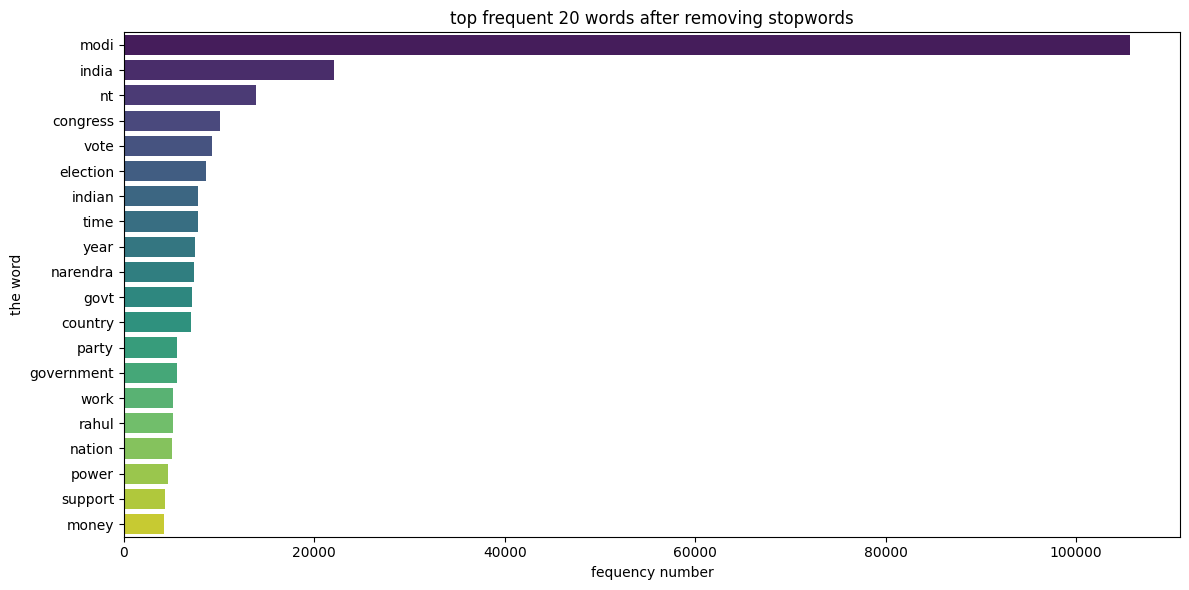

In [20]:

plt.figure(figsize=(12, 6))
freqs = [f for t, f in most_common]
tokens = [t for t, f in most_common]

sns.barplot(x=freqs, y=tokens, palette='viridis')
plt.title('top frequent 20 words after removing stopwords')
plt.xlabel('fequency number')
plt.ylabel('the word')
plt.tight_layout()
plt.show()



In [21]:
def words_count_per_text(x):
    tokens=x.split()
    return len(tokens)

words_sequence_length=df_reindexed['w/o s_w tokens'].apply(words_count_per_text)
words_sequence_length=pd.DataFrame(words_sequence_length)
words_sequence_length=pd.DataFrame(words_sequence_length.value_counts()[:50])
words_sequence_length.reset_index()

,w/o s_w tokens,count
0,5,9183
1,6,9129
2,4,8839
3,7,8633
4,3,8114
5,8,8089
6,9,7386
7,10,6640
8,2,6488
9,11,6350


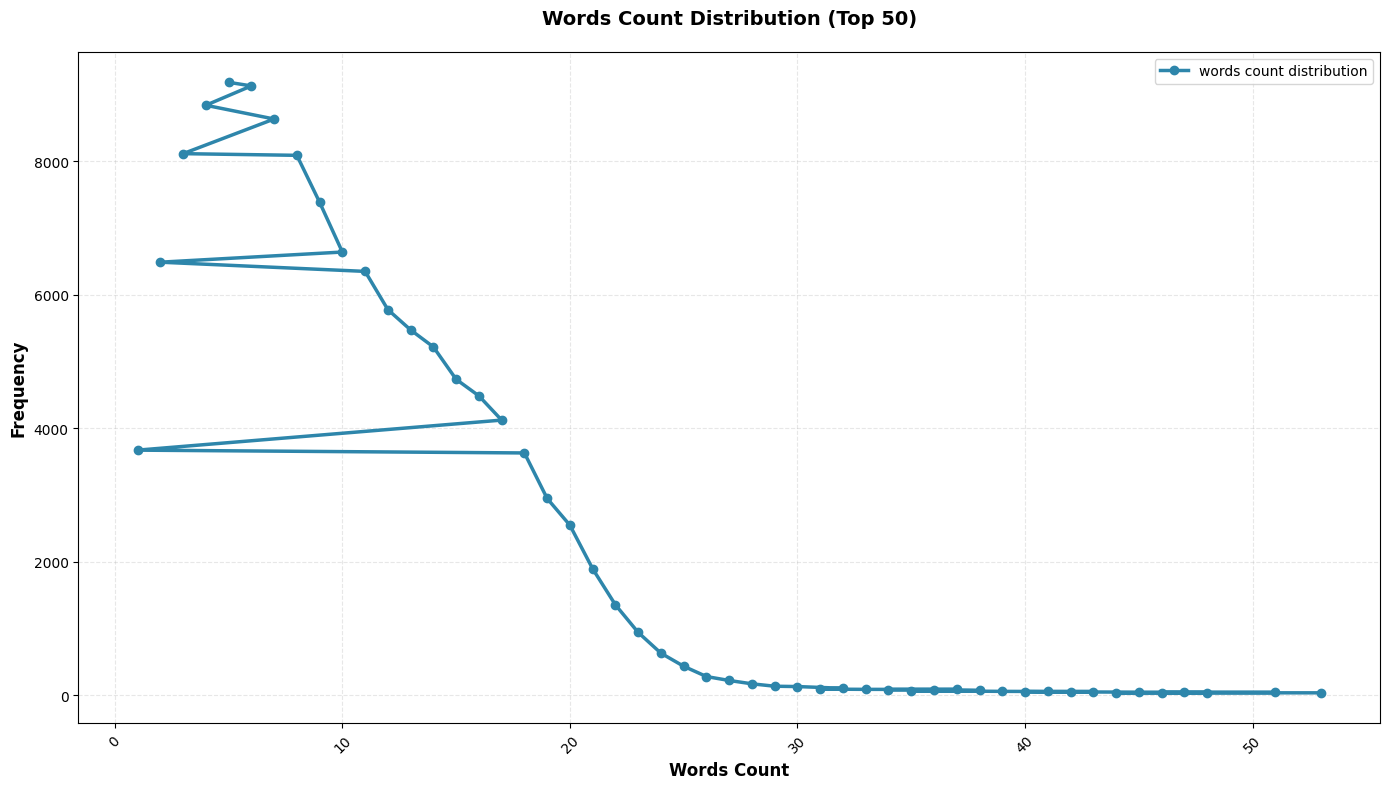

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def words_count_per_text(x):
    tokens = x.split()
    return len(tokens)

words_sequence_length = df_reindexed['w/o s_w tokens'].apply(words_count_per_text)
words_freq = pd.DataFrame(words_sequence_length.value_counts().head(50))
words_freq = words_freq.reset_index()
words_freq.columns = ['words_count', 'frequency']

plt.figure(figsize=(14, 8))
plt.plot(words_freq['words_count'], words_freq['frequency'],
         marker='o', linewidth=2.5, markersize=6,
         color='#2E86AB', label='words count distribution')

plt.xlabel('Words Count', fontsize=12, fontweight='bold')  
plt.ylabel('Frequency', fontsize=12, fontweight='bold')    


plt.title('Words Count Distribution (Top 50)', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

# **7.Bag Of Words Technique**

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
CV=CountVectorizer()
bag_of_words=CV.fit_transform(df_reindexed['w/o s_w tokens'])

In [20]:
Bow_df=pd.DataFrame(bag_of_words.toarray(),columns=CV.get_feature_names_out())


In [21]:
Bow_df

,aah,aaker,aal,aam,aani,aaron,aarti,ab,aback,abandon,...,zona,zonal,zone,zoning,zoo,zoom,zoroastrian,zubin,zuck,zulfikar
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129834,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129835,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129836,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
from sklearn.model_selection import train_test_split
X=bag_of_words
y=new_df['category']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(solver='liblinear')
LR.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogisticRegression(solver='liblinear')

In [24]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix
y_pred=LR.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec_mi = precision_score(y_test, y_pred, average='micro')  
rec_mi = recall_score(y_test, y_pred, average='micro')       
prec_ma = precision_score(y_test, y_pred, average='macro')  
rec_ma = recall_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision (micro):", prec_mi)
print("Recall (micro):",rec_mi)
print("Precision (macro):",prec_ma)
print("Recall (macro):",rec_ma)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7639402341343191
Precision (micro): 0.7639402341343191
Recall (micro): 0.7639402341343191
Precision (macro): 0.7705006448179529
Recall (macro): 0.7648951853964415
Confusion Matrix:
 [[10007  1619  1478]
 [  595 11256   914]
 [ 1531  3058  8494]]


# **8.FastText Embedding**

In [33]:
ft = fasttext.load_model("/kaggle/input/cc-en-300-bin/cc.en.300.bin")
print("vector for 'the' using fasttext:", ft.get_word_vector("the")[:5])

vector for 'the' using fasttext: [-0.05174419  0.07396396 -0.01305688  0.04472656 -0.03432037]


In [34]:
from sklearn.model_selection import train_test_split
y=df_reindexed['category']
X_train, X_test , y_train , y_test=train_test_split(df_reindexed['w/o s_w tokens'],y,random_state=42,test_size=0.2)
X_train2,X_val,y_train2,y_val=train_test_split(X_train,y_train,random_state=42,test_size=0.2)

In [35]:
y_train

88764     2
1959      1
119053    1
69523     2
67940     2
         ..
128106    2
103694    2
860       1
15795     1
121958    1
Name: category, Length: 103945, dtype: int64

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np



tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index  

X_train_seq = tokenizer.texts_to_sequences(X_train2)
X_val_seq = tokenizer.texts_to_sequences(X_val)

sequences_lengths = [len(seq) for seq in X_train_seq]
MAX_SEQUENCE_LENGTH = int(np.percentile(sequences_lengths, 97))
print(MAX_SEQUENCE_LENGTH)

24


In [37]:
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(X_train_padded.shape) 
print(X_val_padded.shape)

(83156, 24)
(20789, 24)


In [21]:
VOCAB_SIZE = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 300

# Create embedding matrix — THIS IS THE ONLY LINE THAT CHANGES
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, i in tokenizer.word_index.items():
    embedding_matrix[i] = ft.get_word_vector(word)   

In [22]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.00732968, -0.11625183, -0.12535642, ...,  0.23565388,
        -0.04996282, -0.01075325],
       [ 0.01269199,  0.03860033, -0.06274948, ...,  0.1171037 ,
        -0.07883091,  0.01106027],
       ...,
       [-0.0160638 , -0.02564487, -0.02918771, ...,  0.06856433,
        -0.02808412, -0.03500078],
       [-0.00966668, -0.02714149,  0.07000275, ...,  0.06251513,
        -0.06326514, -0.0402245 ],
       [ 0.03709757, -0.08213485, -0.10443746, ...,  0.0789259 ,
        -0.03535683, -0.00815719]])

In [23]:
print(VOCAB_SIZE)

24005


# **9.Deep learning model using FastText Embeddings**

In [193]:
from tensorflow.keras.models import Sequential
from keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout

from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, SpatialDropout1D, Conv1D, Bidirectional,RNN, LSTM, Dense, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from keras_self_attention import SeqSelfAttention  # Assuming this package is installed; if not, pip install keras-self-attention
from tensorflow.keras.regularizers import l2

L2=0.001


inputs = Input(shape=(MAX_SEQUENCE_LENGTH,))

embedding = Embedding(
    input_dim=VOCAB_SIZE,                 
    output_dim=EMBEDDING_DIM,                
    input_length=MAX_SEQUENCE_LENGTH,     
    weights=[embedding_matrix],             
    trainable=True,                        
    mask_zero=True,                         
    name='fasttext_embedding'
)(inputs)

# Spatial Dropout 1D
dropout = SpatialDropout1D(0.5)(embedding)  # Dropout rate can be adjusted, e.g., 0.2

# Conv1D layer
conv = Conv1D(filters=128, kernel_size=4, padding='same', activation='relu',kernel_regularizer=l2(L2))(dropout)

# Bidirectional LSTM
lstm1 = LSTM(256, return_sequences=True,recurrent_dropout=0.5,kernel_regularizer=l2(L2))(conv)
lstm2 = LSTM(128, return_sequences=True,recurrent_dropout=0.5,kernel_regularizer=l2(L2))(lstm1)
Dropout(0.5)
# SeqSelfAttention
attention = SeqSelfAttention()(lstm2)

# Global Max Pooling (to flatten for classification)
pooled = GlobalMaxPooling1D()(attention)

# Dense layers for classification (assuming binary sentiment, adjust for your classes)
dense = Dense(64, activation='relu',kernel_regularizer=l2(L2))(pooled)
outputs = Dense(3, activation='softmax')(dense)  # For binary; use softmax for multi-class

# Model
model = Model(inputs=inputs, outputs=outputs)


# Summary
model.build((MAX_SEQUENCE_LENGTH,None))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d_11' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fasttext_embedding (Embedding)  │ (None, 24, 300)        │     7,201,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_11            │ (None, 24, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 24, 256)        │       307,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_5 (RNN)                     │ (None, 24, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq_self_attention_5            │ (None, 24, 256)        │        16,449 │
│ (SeqSelfAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,067,360 (30.77 MB)

 Trainable params: 8,067,360 (30.77 MB)

 Non-trainable params: 0 (0.00 B)

In [194]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))


In [195]:
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [196]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3)
]

history = model.fit(
    X_train_padded, y_train2,
    validation_data=(X_val_padded, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d_11' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1300/1300 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.4994 - loss: 1.3844 - val_accuracy: 0.6870 - val_loss: 0.8834 - learning_rate: 1.0000e-04
Epoch 2/100
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.6904 - loss: 0.8582 - val_accuracy: 0.7395 - val_loss: 0.7491 - learning_rate: 1.0000e-04
Epoch 3/100
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7433 - loss: 0.7223 - val_accuracy: 0.7559 - val_loss: 0.6924 - learning_rate: 1.0000e-04
Epoch 4/100
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7649 - loss: 0.6662 - val_accuracy: 0.7590 - val_loss: 0.6679 - learning_rate: 1.0000e-04
Epoch 5/100
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7765 - loss: 0.6299 - val_accuracy: 0.7672 - val_loss: 0.6544 - learning_rate: 1.0000e-04
Epoch 6/100
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7848 - loss: 0.6074 - val_accuracy: 0.7668 - val_loss: 0.6455 - learning_rate: 1.0000e-04
Epoch 7/100
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 17s

In [197]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = np.argmax(model.predict(X_val_padded, verbose=0), axis=1)
y_true = y_val.ravel() if y_val.ndim == 2 else y_val

print(classification_report(y_true, y_pred, 
                          target_names=['Class 0', 'Class 1', 'Class 2'], digits=4))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))

              precision    recall  f1-score   support

     Class 0     0.8070    0.7944    0.8006      6974
     Class 1     0.7094    0.8912    0.7900      6867
     Class 2     0.8137    0.6203    0.7040      6948

    accuracy                         0.7682     20789
   macro avg     0.7767    0.7686    0.7649     20789
weighted avg     0.7770    0.7682    0.7648     20789

Macro F1: 0.7648599679110122


In [15]:
from transformers import RobertaModel, RobertaTokenizer
import torch

In [16]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


In [17]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model = RobertaModel.from_pretrained('cardiffnlp/twitter-roberta-base-sentiment-latest',output_hidden_states=True)

# **10.Roberta Model Tokenizer Embeddings**

In [18]:
import os
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

# ================================
# 1. SETTINGS – YOUR CHOICE
# ================================
BATCH_SIZE = 16          # ← fixed to 8 as requested
MAX_LENGTH = 24         # perfect for your data
N_SAMPLES  = len(df_reindexed)                       # e.g. 129932
EMB_SHAPE  = (N_SAMPLES, MAX_LENGTH, 3072)
output_file = 'twitter_roberta_embeddings_130k.npy'

print(f"Processing {N_SAMPLES:,} texts with batch_size=8 → saving to {output_file}")

# ================================
# 2. Memory-mapped file (NO RAM CRASH EVER)
# ================================
if os.path.exists(output_file):
    os.remove(output_file)

final_embeddings = np.memmap(
    output_file,
    dtype=np.float16,
    mode='write',
    shape=EMB_SHAPE
)

# ================================
# 3. Load model (clean & modern)
# ================================
tokenizer = AutoTokenizer.from_pretrained('cardiffnlp/twitter-roberta-base-sentiment-latest')
model = AutoModel.from_pretrained(
    'cardiffnlp/twitter-roberta-base-sentiment-latest',
    output_hidden_states=True,
    dtype=torch.float16
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
print(f"Using device: {device}")

# ================================
# 4. Batched inference – write directly to disk
# ================================
texts = df_reindexed['clean_text'].astype(str).tolist()
start_idx = 0

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i:i + BATCH_SIZE]

    encoded = tokenizer(
        batch_texts,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    # Last 4 layers → 3072 dim
    batch_emb = torch.cat(outputs.hidden_states[-4:], dim=-1)      # (≤8, 24, 3072)
    batch_np = batch_emb.to(torch.float16).cpu().numpy()

    # Write straight to disk
    end_idx = start_idx + batch_np.shape[0]
    final_embeddings[start_idx:end_idx] = batch_np
    start_idx = end_idx

    # Clean GPU
    del input_ids, attention_mask, outputs, batch_emb, batch_np
    torch.cuda.empty_cache()

# ================================
# 5. Done!
# ================================
final_embeddings.flush()
print("\nDONE! Embeddings saved safely (batch_size=8)")
print(f"File: {output_file}")
print(f"Shape: {final_embeddings.shape}")
print(f"Disk size: {os.path.getsize(output_file)/1e9:.2f} GB")

Processing 129,932 texts with batch_size=8 → saving to twitter_roberta_embeddings_130k.npy
Using device: cuda


100%|██████████| 8121/8121 [02:59<00:00, 45.16it/s]


DONE! Embeddings saved safely (batch_size=8)
File: twitter_roberta_embeddings_130k.npy
Shape: (129932, 24, 3072)
Disk size: 19.16 GB


In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalMaxPooling1D, SpatialDropout1D
from tensorflow.keras.layers import Conv1D, Bidirectional, LSTM
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.regularizers import l2

# ================================
# 1. Load your embeddings (memory-mapped = no RAM crash)
# ================================
N_SAMPLES  = 129932
MAX_LENGTH = 24
EMBEDDING_DIM = 3072

embeddings_file = '/kaggle/working/twitter_roberta_embeddings_130k.npy'

# This loads almost ZERO RAM — only what you access
roberta_embeddings = np.memmap(
    embeddings_file,
    dtype=np.float16,
    mode='r',
    shape=(N_SAMPLES, MAX_LENGTH, EMBEDDING_DIM)
)

print(f"Loaded RoBERTa embeddings: {roberta_embeddings.shape}")

Loaded RoBERTa embeddings: (129932, 24, 3072)


# **11.Train Test Split**

In [20]:
import numpy as np

total = len(df_reindexed)          # → 129932

# Your desired ratios
train_ratio = 0.80   # 60% train
val_ratio   = 0.10   # 20% validation
test_ratio  = 0.10   # 20% test

# Exact sizes (with proper rounding)
train_size = int(total * train_ratio)   # → 77,959
val_size   = int(total * val_ratio)     # → 25,986
test_size  = total - train_size - val_size  # → 25,987 (due to rounding)

# Correct sequential indices (no overlap!)
train_indx = np.arange(0, train_size)                    # 0 → 77,958
val_indx   = np.arange(train_size, train_size + val_size) # 77,959 → 103,944
test_indx  = np.arange(train_size + val_size, total)     # 103,945 → 129,931

# Print results
print(f"Total samples : {total:,}")
print(f"Train (80%)   : {len(train_indx):,} → indices {train_indx[0]} to {train_indx[-1]}")
print(f"Val (10%)     : {len(val_indx):,} → indices {val_indx[0]} to {val_indx[-1]}")
print(f"Test (10%)    : {len(test_indx):,} → indices {test_indx[0]} to {test_indx[-1]}")
print(f"Sum check     : {len(train_indx) + len(val_indx) + len(test_indx):,} (should be {total:,})")

Total samples : 129,932
Train (80%)   : 103,945 → indices 0 to 103944
Val (10%)     : 12,993 → indices 103945 to 116937
Test (10%)    : 12,994 → indices 116938 to 129931
Sum check     : 129,932 (should be 129,932)


In [21]:
import os

In [22]:
checkpoint_dir = './training_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Checkpoint every epoch → ckpt_0001.keras, ckpt_0002.keras, etc.
epoch_checkpoint_path = os.path.join(checkpoint_dir, "ckpt_{epoch:04d}.keras")

# Best model → saved as a single file
best_model_path = os.path.join(checkpoint_dir, "best_model.keras")

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, SpatialDropout1D, Conv1D, LSTM,Bidirectional,
                                     Dense, Dropout, GlobalMaxPooling1D)
from keras_self_attention import SeqSelfAttention
from tensorflow.keras import regularizers


# ================================
# 2. Labels
# ================================
labels = df_reindexed['category'].values.astype(np.int32)

# ================================
# 3. Load embeddings
# ================================
embeddings = np.memmap(
    'twitter_roberta_embeddings_130k.npy',
    dtype='float16',
    mode='r',
    shape=(129932, 24, 3072)
)

# ================================
# 4. P100-SAFE tf.data (BATCH_SIZE=4 is the magic)
# ================================
BATCH_SIZE = 64   # ← THIS + 2 fixes below = no OOM

def make_dataset(indices, labels, shuffle=False):
    def gen():
        for i in indices:
            yield embeddings[i].astype('float32'), labels[i]
    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(24, 3072), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )
    if shuffle:
        ds = ds.shuffle(500)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_indx, labels, shuffle=True)
val_ds   = make_dataset(val_indx,   labels)
test_ds  = make_dataset(test_indx,  labels)

# ================================
# 5. YOUR EXACT ARCHITECTURE — BUT P100-SAFE!
# ================================
inputs = Input(shape=(24, 3072), dtype='float32')

x = SpatialDropout1D(0.4)(inputs)

x = Dense(512, activation='elu')(x)     

x = Conv1D(filters=512, kernel_size=3, padding='same', activation='elu',kernel_regularizer=regularizers.L2(l2=1e-2))(x)


x =Bidirectional(LSTM(1024, return_sequences=True,recurrent_dropout=0.4,kernel_regularizer=regularizers.L2(l2=1e-2)))(x)     # ← recurrent_dropout=0 !!
x = Bidirectional(LSTM(1024, return_sequences=True,recurrent_dropout=0.4,kernel_regularizer=regularizers.L2(l2=1e-2)))(x)
x = Dropout(0.4)(x)
x = SeqSelfAttention()(x)
x = GlobalMaxPooling1D()(x)
x = Dense(128, activation='elu',kernel_regularizer=regularizers.L2(l2=1e-2))(x)
x = Dense(64, activation='elu',kernel_regularizer=regularizers.L2(l2=1e-2))(x)

outputs = Dense(3, activation='softmax')(x)   # ← change 3 if needed

model = Model(inputs, outputs)



model.summary()

I0000 00:00:1764428443.191340      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14709 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 3072)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 24, 3072)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 512)        │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 512)        │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 2048)       │    12,591,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 24, 2048)       │    25,174,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq_self_attention              │ (None, 24, 2048)       │       131,137 │
│ (SeqSelfAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,527,300 (154.60 MB)

 Trainable params: 40,527,300 (154.60 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
!rm -rf /kaggle/working/training_checkpoints
print("training_checkpoints folder DELETED permanently!")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


training_checkpoints folder DELETED permanently!


In [ ]:
import shutil
import os

checkpoint_dir = '/kaggle/working/training_checkpoints'

if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)
    print("Entire training_checkpoints directory DELETED")
else:
    print(" Directory doesn't exist")

In [45]:
checkpoint_dir = './training_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)



# **12.Best Classical Deep Learning model using Roberta Tokenizer Emeddings with Best Accuracy**

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, SpatialDropout1D, Conv1D, LSTM,Bidirectional,
                                     Dense, Dropout, GlobalMaxPooling1D)
from keras_self_attention import SeqSelfAttention
from tensorflow.keras import regularizers




labels = df_reindexed['category'].values.astype(np.int32)



embeddings = np.memmap(
    'twitter_roberta_embeddings_130k.npy',
    dtype='float16',
    mode='r',
    shape=(129932, 24, 3072)
)



BATCH_SIZE = 64   

def make_dataset(indices, labels, shuffle=False):
    def gen():
        for i in indices:
            yield embeddings[i].astype('float32'), labels[i]
    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(24, 3072), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )
    if shuffle:
        ds = ds.shuffle(500)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_indx, labels, shuffle=True)
val_ds   = make_dataset(val_indx,   labels)
test_ds  = make_dataset(test_indx,  labels)



inputs = Input(shape=(24, 3072), dtype='float32')

x = SpatialDropout1D(0.4)(inputs)

x = Dense(512, activation='elu')(x)        # ← NEW: 3072 → 512

x = Conv1D(filters=512, kernel_size=3, padding='same', activation='elu',kernel_regularizer=regularizers.L2(l2=1e-3))(x)

# CRITICAL: remove recurrent_dropout → allows cuDNN (10× faster, 5× less memory)
x = Bidirectional(LSTM(1024, return_sequences=True,recurrent_dropout=0.4,kernel_regularizer=regularizers.L2(l2=1e-3)))(x)     
x = Bidirectional(LSTM(512, return_sequences=True,recurrent_dropout=0.4,kernel_regularizer=regularizers.L2(l2=1e-3)))(x)
x = Bidirectional(LSTM(256, return_sequences=True,recurrent_dropout=0.4,kernel_regularizer=regularizers.L2(l2=1e-3)))(x)    
x = Bidirectional(LSTM(128, return_sequences=True,recurrent_dropout=0.4,kernel_regularizer=regularizers.L2(l2=1e-3)))(x)
x = Dropout(0.4)(x)
x = SeqSelfAttention()(x)
x = GlobalMaxPooling1D()(x)
x = Dense(128, activation='elu',kernel_regularizer=regularizers.L2(l2=1e-3))(x)
x = Dense(64, activation='elu',kernel_regularizer=regularizers.L2(l2=1e-3))(x)
x = Dropout(0.4)(x)
outputs = Dense(3, activation='softmax')(x)  

model = Model(inputs, outputs)



model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 3072)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 24, 3072)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24, 512)        │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 512)        │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 24, 2048)       │    12,591,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 24, 1024)       │    10,489,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 24, 512)        │     2,623,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 24, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq_self_attention_1            │ (None, 24, 256)        │        16,449 │
│ (SeqSelfAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,778,948 (109.78 MB)

 Trainable params: 28,778,948 (109.78 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
import tensorflow as tf
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping



checkpoint_dir = "/kaggle/working/training_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)



callbacks = [

    
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, "ckpt_{epoch:04d}.keras"),
        save_weights_only=False,   # full model + optimizer state
        save_freq='epoch',
        verbose=1
    ),


    
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, "best_model.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        save_weights_only=False,
        verbose=1
    ),

    # 3. Stop early if no improvement
    EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),
]




print("Starting training from scratch → creating checkpoints...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=32,
    epochs=3,                    
    callbacks=callbacks,
    verbose=1
)

print("First training completed!")
print(f"Checkpoints saved in: {checkpoint_dir}")
print("Files created:")
print("  → best_model.keras        (best performing model)")
print("  → ckpt_0001.keras to ckpt_0050.keras  (one per epoch)")

print("\nYou can now CLOSE this notebook and use your RESUME script forever!")
print("It will automatically load best_model.keras or the latest ckpt_*.keras")

Starting training from scratch → creating checkpoints...
Epoch 1/3


I0000 00:00:1764428495.595037     242 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1625/Unknown 718s 428ms/step - accuracy: 0.5516 - loss: 5.8342

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: saving model to /kaggle/working/training_checkpoints/ckpt_0001.keras

Epoch 1: val_accuracy improved from -inf to 0.60864, saving model to /kaggle/working/training_checkpoints/best_model.keras
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 743s 444ms/step - accuracy: 0.5516 - loss: 5.8329 - val_accuracy: 0.6086 - val_loss: 1.6329
Epoch 2/3
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.6072 - loss: 1.4481
Epoch 2: saving model to /kaggle/working/training_checkpoints/ckpt_0002.keras

Epoch 2: val_accuracy improved from 0.60864 to 0.65882, saving model to /kaggle/working/training_checkpoints/best_model.keras
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 707s 435ms/step - accuracy: 0.6072 - loss: 1.4480 - val_accuracy: 0.6588 - val_loss: 1.0426
Epoch 3/3
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6638 - loss: 1.0008
Epoch 3: saving model to /kaggle/working/training_checkpoints/ckpt_0003.keras

Epoch 3: val_accuracy improved from 0.65882 to 0.71823, saving model to /kaggle/working/t

In [56]:
best_model = tf.keras.models.load_model('./training_checkpoints/best_model.keras')

In [ ]:
import tensorflow as tf
import os
import glob
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau




checkpoint_dir = "/kaggle/working/training_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_model_path   = os.path.join(checkpoint_dir, "best_model.keras")
latest_model_path = os.path.join(checkpoint_dir, "latest_model.keras")

# Remove all old ckpt_*.keras files
old_ckpts = glob.glob(os.path.join(checkpoint_dir, "ckpt_*.keras"))
for f in old_ckpts:
    try:
        os.remove(f)
        print(f"Removed old checkpoint: {os.path.basename(f)}")
    except Exception as e:
        print(f"Failed to remove {os.path.basename(f)} → {e}")

if old_ckpts:
    print(f"Cleaned {len(old_ckpts)} old numbered checkpoint(s). Starting fresh!")
else:
    print("No old ckpt_*.keras files found.")

print("-" * 60)



def load_existing_model():
    # 1. Best model first
    if os.path.exists(best_model_path):
        try:
            model = tf.keras.models.load_model(best_model_path)
            print("Loaded best_model.keras (highest val_accuracy ever)")
            return model, 0
        except Exception as e:
            print(f"best_model.keras corrupted →", e)

    # 2. Latest model
    if os.path.exists(latest_model_path):
        try:
            model = tf.keras.models.load_model(latest_model_path)
            print("best_model not available → loaded latest_model.keras")
            return model, 0
        except Exception as e:
            print(f"latest_model.keras corrupted →", e)

    # 3. Fallback: newest uncorrupted ckpt_*.keras
    ckpt_files = glob.glob(os.path.join(checkpoint_dir, "ckpt_*.keras"))
    ckpt_files.sort(key=os.path.getctime, reverse=True)  # newest first

    for f in ckpt_files:
        try:
            epoch = int(os.path.basename(f).split('_')[1].split('.')[0])
            model = tf.keras.models.load_model(f)
            print(f"Fallback → loaded {os.path.basename(f)} (epoch {epoch})")
            return model, epoch
        except Exception as e:
            print(f"Corrupted → skipping {os.path.basename(f)}")

    raise FileNotFoundError("No valid model found! Train from scratch first.")


model, initial_epoch = load_existing_model()



callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-10, verbose=1),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    ModelCheckpoint(
        filepath=latest_model_path,
        save_best_only=False, 
        verbose=1
    ),
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=32,
    epochs=50,                    
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING FINISHED!")
print(f"Best model   → {best_model_path}")
print(f"Latest model → {latest_model_path}")
print("No more ckpt_XXXX.keras clutter — ever again!")
print("="*60)

No old ckpt_*.keras files found.
------------------------------------------------------------
Loaded best_model.keras (highest val_accuracy ever)
Epoch 1/50
   1625/Unknown 710s 425ms/step - accuracy: 0.7536 - loss: 0.6282
Epoch 1: val_accuracy improved from -inf to 0.76641, saving model to /kaggle/working/training_checkpoints/best_model.keras

Epoch 1: saving model to /kaggle/working/training_checkpoints/latest_model.keras
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 736s 441ms/step - accuracy: 0.7536 - loss: 0.6281 - val_accuracy: 0.7664 - val_loss: 0.6103 - learning_rate: 1.0000e-04
Epoch 2/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.7628 - loss: 0.6114
Epoch 2: val_accuracy improved from 0.76641 to 0.76965, saving model to /kaggle/working/training_checkpoints/best_model.keras

Epoch 2: saving model to /kaggle/working/training_checkpoints/latest_model.keras
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 716s 441ms/step - accuracy: 0.7628 - loss: 0.6114 - val_accuracy: 0.7696 - val_loss: 0.6005 

In [ ]:
h5_roberta_tokenizer=model.save('roberta_tokenizer_model.h5') 
keras_roberta_tokenizer=model.save('roberta_tokenizer_model.keras') 

# **13.Full Modern Roberta Model for Sentimental Analysis**

In [23]:

import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [24]:
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,  
)
import torch



hg_dataset = Dataset.from_pandas(new_df[['text', 'category']])
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    tokenized["labels"] = examples["category"]
    return tokenized

tokenized_datasets = hg_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "category"]
)

train_test = tokenized_datasets.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test['train']
eval_dataset = train_test['test']

train_dataset.set_format("torch")
eval_dataset.set_format("torch")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    return {
        "accuracy": acc,
        "f1_weighted": f1,
        "precision_weighted": precision,
        "recall_weighted": recall,
    }

training_args = TrainingArguments(
    output_dir="twitter_sentiment_final",
    eval_strategy="epoch",
    save_strategy="epoch",                 
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    weight_decay=0.001,
    load_best_model_at_end=True,           
    metric_for_best_model="f1_weighted",  
    greater_is_better=True,              
    logging_steps=50,
    fp16=True,
    report_to="none",
    seed=42,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer, 
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1,        
            early_stopping_threshold=0.001     
        )
    ],
)

trainer.train()

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

...

Map:   0%|          | 0/129932 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

/tmp/ipykernel_38/2972128360.py:76: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.217300,0.200795,0.952746,0.952814,0.953624,0.952746
2,0.159700,0.142557,0.968600,0.968656,0.968816,0.968600
3,0.124300,0.159891,0.970370,0.970444,0.971102,0.970370
4,0.082900,0.135551,0.977566,0.977582,0.977631,0.977566
5,0.071300,0.136151,0.978181,0.978188,0.978305,0.978181


TrainOutput(global_step=64970, training_loss=0.1326609429185879, metrics={'train_runtime': 8566.0172, 'train_samples_per_second': 72.807, 'train_steps_per_second': 9.102, 'total_flos': 3.41866552571712e+16, 'train_loss': 0.1326609429185879, 'epoch': 5.0})

# **14.Evaluation Metrics for Roberta Sentimental Analyzer model**

In [28]:
results = trainer.evaluate()

print("all available metrics:")
for key, value in results.items():
    print(f"  {key}: {value:.4f}")

print("\n" + "="*50)
print("final assessment results:")
print(f" (Accuracy):        {results['eval_accuracy']:.4f}")
print(f" (F1):    {results['eval_f1_weighted']:.4f}")
print(f" (Precision):      {results['eval_precision_weighted']:.4f}")
print(f"  (Recall):     {results['eval_recall_weighted']:.4f}")
print(f" number of samples:           {results['eval_runtime']:.1f} second")
print("="*50)

import pandas as pd
metrics_df = pd.DataFrame({
    'اmetric': ['Accuracy', 'F1-Score', 'Precision', 'Recall'],
    'value': [
        f"{results['eval_accuracy']:.4f}",
        f"{results['eval_f1_weighted']:.4f}",
        f"{results['eval_precision_weighted']:.4f}",
        f"{results['eval_recall_weighted']:.4f}"
    ]
})
print(metrics_df)

all available metrics:
  eval_loss: 0.1362
  eval_accuracy: 0.9782
  eval_f1_weighted: 0.9782
  eval_precision_weighted: 0.9783
  eval_recall_weighted: 0.9782
  eval_runtime: 96.4787
  eval_samples_per_second: 269.3550
  eval_steps_per_second: 16.8430
  epoch: 5.0000

final assessment results:
 (Accuracy):        0.9782
 (F1):    0.9782
 (Precision):      0.9783
  (Recall):     0.9782
 number of samples:           96.5 second
     اmetric   value
0   Accuracy  0.9782
1   F1-Score  0.9782
2  Precision  0.9783
3     Recall  0.9782


# **15.User Input sentimental analysis Classification using Roberta Model**

In [30]:
from transformers import pipeline
import torch

print("model is being loaded")
classifier = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    top_k=None,
    device=0 if torch.cuda.is_available() else -1
)
print("Model is loaded Succesfully")


def predict_sentiment(text):

    raw_results = classifier(text)
    

    results = raw_results[0]  
    
    print("\n" + "="*70)
    print(f" text: {text}")
    

    best_result = max(results, key=lambda x: x['score'])
    
    
    label_mapping = {
        "positive": "positive",
        "neutral": "neutral", 
        "negative": "negative"
    }
    
    sentiment = label_mapping.get(best_result['label'], "غير معروف")
    confidence = best_result['score'] * 100
    
    print(f"\n sentiment: {sentiment}")
    print(f"confidence: {confidence:.2f}%")
    

    print("\n Condfidence distribution")
    print("-" * 40)
    for i, result in enumerate(results, 1):
        label = label_mapping.get(result['label'], result['label'])
        percentage = result['score'] * 100
        print(f"   {i}. {label:<12} | {percentage:6.2f}%")
    
    print("="*70)
    return sentiment, confidence

# User Input
print("\n" + " Sentiment analyzer using Artificial Intelligence ")
print("="*70)

while True:
    try:
        text = input('\n please insert the sentimental message , and to exit type "exit","quit","خروج",or "توقف":\n')
        
        if text.lower() in ['exit', 'quit', 'خروج', 'توقف']:
            print(" Thank you for using our sentimental analyzer ")
            break
        
        if text.strip():  
            output = predict_sentiment(text)
        else:
            print("please insert a valid text input!!")
            
    except KeyboardInterrupt:
        print("\n\n The Application has stopped using the user!!")
        break
    except Exception as e:
        print(f" Unexpected Error: {e}")

print("\n The program has Successfuly Ended !!")

model is being loaded


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Model is loaded Succesfully

 Sentiment analyzer using Artificial Intelligence 



 please insert the sentimental message , and to exit type "exit","quit","خروج",or "توقف":
 hello bad guy



 text: hello bad guy

 sentiment: negative
confidence: 64.58%

 Condfidence distribution
----------------------------------------
   1. negative     |  64.58%
   2. neutral      |  29.70%
   3. positive     |   5.72%



 please insert the sentimental message , and to exit type "exit","quit","خروج",or "توقف":
 exit


 Thank you for using our sentimental analyzer 

 The program has Successfuly Ended !!



 text: god is great

 sentiment: positive
confidence: 94.83%

 Condfidence distribution
----------------------------------------
   1. positive     |  94.83%
   2. neutral      |   3.50%
   3. negative     |   1.68%



 please insert the sentimental message , and to exit type "exit","quit","خروج",or "توقف":
 exit


 Thank you for using our sentimental analyzer 

 The program has Successfuly Ended !!


# **16.Saving Roberta Model to be used later**

In [29]:
pytorch_path = "/kaggle/working/sentiment_model_pytorch"
model.save_pretrained(pytorch_path)
tokenizer.save_pretrained(pytorch_path)

print("saved as pytorch")
!ls -la {pytorch_path}

saved as pytorch
total 491656
drwxr-xr-x 2 root root      4096 Dec  6 18:33 .
drwxr-xr-x 5 root root      4096 Dec  6 18:33 ..
-rw-r--r-- 1 root root       887 Dec  6 18:33 config.json
-rw-r--r-- 1 root root    456318 Dec  6 18:33 merges.txt
-rw-r--r-- 1 root root 498615900 Dec  6 18:33 model.safetensors
-rw-r--r-- 1 root root       958 Dec  6 18:33 special_tokens_map.json
-rw-r--r-- 1 root root      1274 Dec  6 18:33 tokenizer_config.json
-rw-r--r-- 1 root root   3558908 Dec  6 18:33 tokenizer.json
-rw-r--r-- 1 root root    798293 Dec  6 18:33 vocab.json


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
